# Cataract Classification with ResNet-50



## 0. 檢查 GPU

In [27]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("沒有 GPU,請到執行階段 → 變更執行階段類型選 GPU")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. 設定 Kaggle 並下載資料集

In [28]:
from google.colab import files
print("請上傳你的 kaggle.json 檔案:")
uploaded = files.upload()  # 選擇 kaggle.json

請上傳你的 kaggle.json 檔案:


Saving kaggle.json to kaggle (1).json


In [29]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
print("Kaggle 設定完成")

Kaggle 設定完成


In [30]:
!kaggle datasets download -d akshayramakrishnan28/cataract-classification-dataset
!unzip -o -q cataract-classification-dataset.zip -d /content/cataract_data
print("下載與解壓完成")

Dataset URL: https://www.kaggle.com/datasets/akshayramakrishnan28/cataract-classification-dataset
License(s): CC-BY-SA-4.0
cataract-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
下載與解壓完成


In [31]:
import os
BASE = '/content/cataract_data'

print("=== 資料夾結構 ===")
for root, dirs, fs in os.walk(BASE):
    depth = root.replace(BASE, '').count(os.sep)
    if depth <= 2:
        print('  ' * depth + os.path.basename(root) + f'/   ({len(fs)} files)')

TRAIN_DIR = None
for root, dirs, fs in os.walk(BASE):
    if os.path.basename(root).lower() == 'train' and len(dirs) >= 2:
        TRAIN_DIR = root
        break
if TRAIN_DIR is None:
    for root, dirs, fs in os.walk(BASE):
        if len(dirs) >= 2:
            sub = os.path.join(root, dirs[0])
            if any(f.lower().endswith(('.jpg','.jpeg','.png')) for f in os.listdir(sub)):
                TRAIN_DIR = root
                break

print("\n=> TRAIN_DIR:", TRAIN_DIR)
assert TRAIN_DIR is not None, "找不到資料夾,請依上面結構手動設定 TRAIN_DIR"
print("類別:", sorted(os.listdir(TRAIN_DIR)))

=== 資料夾結構 ===
cataract_data/   (0 files)
  train/   (0 files)
    mature/   (196 files)
    immature/   (214 files)

=> TRAIN_DIR: /content/cataract_data/train
類別: ['immature', 'mature']


In [32]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
import numpy as np
import random, re, copy
from collections import Counter

torch.manual_seed(0); random.seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [33]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

In [34]:
dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform_train)
classes = dataset.classes
targets = np.array(dataset.targets)
print("classes:", classes)
print("total images:", len(dataset))
print("各類別數量:", {classes[k]: int(v) for k, v in sorted(Counter(targets).items())})

classes: ['immature', 'mature']
total images: 410
各類別數量: {'immature': 214, 'mature': 196}


## 4. 依原圖分組切割 (避免資料洩漏)

因為資料集每張原圖都被增強複製過。若直接隨機切割,同一張原圖的原版與增強版可能分屬 train / test,
等於測試時看過訓練的圖,會把準確率灌高。下面用檔名把同一張原圖的所有衍生版本綁成一組,
確保整組只落在 train 或 test。

In [35]:
def group_key(path):
    """從檔名取出原圖群組鍵。Roboflow 增強檔名為 原名_jpg.rf.<hash>.jpg"""
    name = os.path.basename(path)
    stripped = re.sub(r'\.rf\.[0-9a-fA-F]+\.\w+$', '', name)  # 去掉 .rf.<hash>.<ext>
    if stripped == name:                       # 沒有 roboflow 命名 -> 退回用檔名(不含副檔名)
        stripped = os.path.splitext(name)[0]
    return stripped

groups = np.array([group_key(p) for p, _ in dataset.samples])
n_files, n_groups = len(groups), len(set(groups))
print(f"檔案數: {n_files} | 不重複原圖群組數: {n_groups}")
if n_groups < n_files:
    print("→ 偵測到增強重複,使用依原圖分組切割。")
else:
    print("→ 未偵測到分組規則,等同一般隨機切割。")

檔案數: 410 | 不重複原圖群組數: 66
→ 偵測到增強重複,使用依原圖分組切割。


In [36]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
train_idx, test_idx = next(gss.split(np.arange(n_files), targets, groups))

train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset  = torch.utils.data.Subset(dataset, test_idx)

# 確認沒有任何原圖群組同時出現在 train 與 test
overlap = set(groups[train_idx]) & set(groups[test_idx])
print("train/test 群組重疊數:", len(overlap))

def count_from_idx(idx):
    return {classes[k]: int(v) for k, v in sorted(Counter(targets[idx]).items())}
print("Train:", len(train_idx), count_from_idx(train_idx))
print("Test :", len(test_idx),  count_from_idx(test_idx))

train/test 群組重疊數: 0
Train: 340 {'immature': 196, 'mature': 144}
Test : 70 {'immature': 18, 'mature': 52}


In [37]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

## 5. 視覺化影像

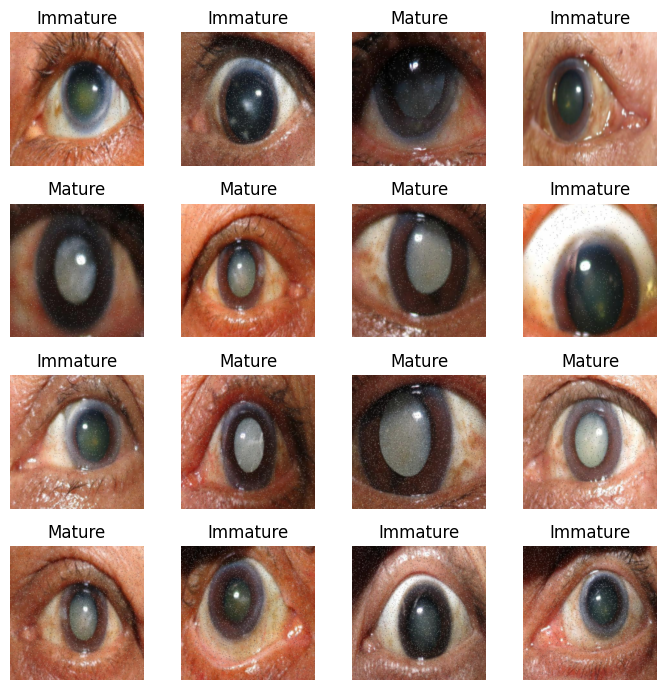

In [38]:
def unnormalize_img(np_image):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    npimg = np.transpose(np_image, (1, 2, 0))
    return np.clip((npimg * std) + mean, 0, 1)

dataiter = iter(train_loader)
images, labels = next(dataiter)

f, axarr = plt.subplots(4, 4, figsize=(7, 7))
for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        axarr[i, j].imshow(unnormalize_img(images[idx].numpy()))
        axarr[i, j].axis("off")
        axarr[i, j].set_title(classes[labels[idx]].capitalize())
plt.tight_layout(); plt.show()

## 6. 建立 ResNet-50 模型

In [39]:
def build_model():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    for p in model.parameters():
        p.requires_grad = True
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Linear(in_features, 1), nn.Sigmoid())
    return model.to(device)

model = build_model()
learning_rate = 0.01
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)

## 7. 模型訓練

In [40]:
def train_model(model, train_loader, optimizer, criterion, epochs=12,
                val_loader=None, early_stopping=False, early_stopping_patience=5):
    if val_loader is None and early_stopping:
        raise ValueError("Early stopping 需要驗證資料")

    best_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    patience = early_stopping_patience
    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        losses, correct, total = [], 0, 0
        for x, y in train_loader:
            optimizer.zero_grad()
            x = x.to(device).float()
            y = y.unsqueeze(1).float().to(device)
            out = model(x)
            loss = criterion(out, y)
            loss.backward(); optimizer.step()
            losses.append(loss.item())
            correct += ((out >= 0.5).float() == y).sum().item()
            total += y.size(0)
        tr_loss, tr_acc = sum(losses)/len(losses), 100*correct/total
        history['train_loss'].append(tr_loss); history['train_accuracy'].append(tr_acc)
        msg = f"Epoch {epoch+1} | Train Loss {tr_loss:.4f} | Train Acc {tr_acc:.2f}%"

        if val_loader is not None:
            model.eval(); vlosses, vcorrect, vtotal = [], 0, 0
            with torch.no_grad():
                for x, y in val_loader:
                    x = x.to(device).float()
                    y = y.unsqueeze(1).float().to(device)
                    out = model(x)
                    vlosses.append(criterion(out, y).item())
                    vcorrect += ((out >= 0.5).float() == y).sum().item()
                    vtotal += y.size(0)
            v_loss, v_acc = sum(vlosses)/len(vlosses), 100*vcorrect/vtotal
            history['val_loss'].append(v_loss); history['val_accuracy'].append(v_acc)
            msg += f" | Val Loss {v_loss:.4f} | Val Acc {v_acc:.2f}%"
        print(msg)

        if early_stopping:
            if v_loss < best_loss:
                best_loss = v_loss
                best_weights = copy.deepcopy(model.state_dict())
                patience = early_stopping_patience
            else:
                patience -= 1
                if patience == 0:
                    print("Early stopping."); break

    model.load_state_dict(best_weights)
    return model, history

In [41]:
num_epochs = 10
model, history = train_model(model, train_loader, optimizer, criterion,
                             num_epochs, test_loader, early_stopping=True,
                             early_stopping_patience=3)

Epoch 1 | Train Loss 0.5616 | Train Acc 72.06% | Val Loss 0.4059 | Val Acc 94.29%
Epoch 2 | Train Loss 0.1187 | Train Acc 97.35% | Val Loss 0.1095 | Val Acc 97.14%
Epoch 3 | Train Loss 0.0310 | Train Acc 99.41% | Val Loss 0.0565 | Val Acc 100.00%
Epoch 4 | Train Loss 0.0088 | Train Acc 100.00% | Val Loss 0.0193 | Val Acc 100.00%
Epoch 5 | Train Loss 0.0027 | Train Acc 100.00% | Val Loss 0.0103 | Val Acc 100.00%
Epoch 6 | Train Loss 0.0009 | Train Acc 100.00% | Val Loss 0.0109 | Val Acc 100.00%
Epoch 7 | Train Loss 0.0045 | Train Acc 100.00% | Val Loss 0.0086 | Val Acc 100.00%
Epoch 8 | Train Loss 0.0072 | Train Acc 100.00% | Val Loss 0.0077 | Val Acc 100.00%
Epoch 9 | Train Loss 0.0196 | Train Acc 99.71% | Val Loss 0.0245 | Val Acc 100.00%
Epoch 10 | Train Loss 0.0065 | Train Acc 100.00% | Val Loss 0.0156 | Val Acc 100.00%


## 8. Accuracy 曲線 & Loss 曲線

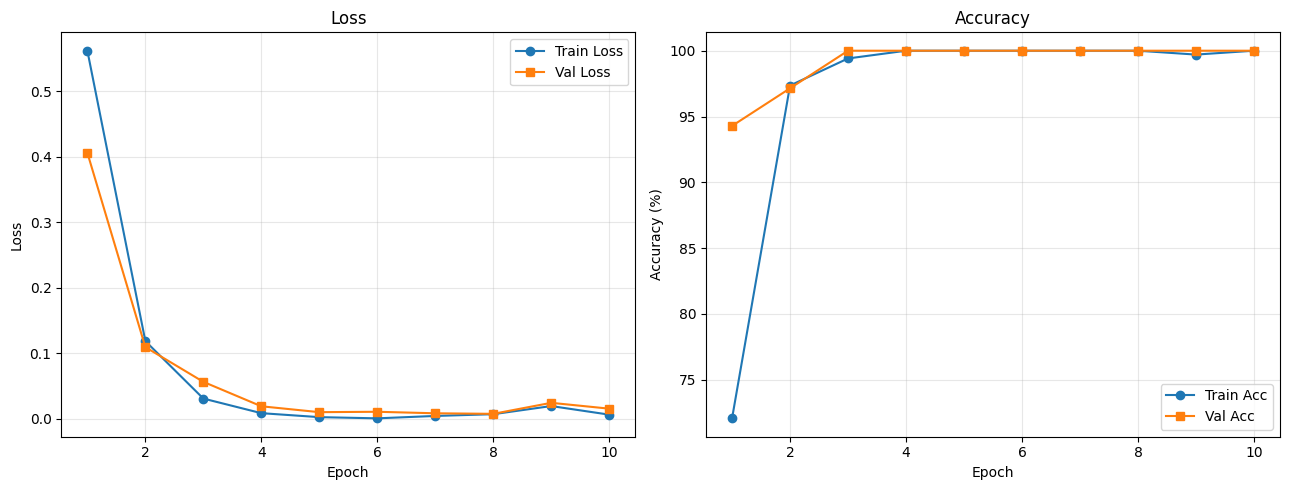

In [42]:
epochs_ran = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, history['train_loss'], 'o-', label='Train Loss')
plt.plot(epochs_ran, history['val_loss'],  's-', label='Val Loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, history['train_accuracy'], 'o-', label='Train Acc')
plt.plot(epochs_ran, history['val_accuracy'],  's-', label='Val Acc')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 9. 評估: Confusion Matrix + Precision / Recall / F1

Test Accuracy: 100.00%

              precision    recall  f1-score   support

    immature     1.0000    1.0000    1.0000        18
      mature     1.0000    1.0000    1.0000        52

    accuracy                         1.0000        70
   macro avg     1.0000    1.0000    1.0000        70
weighted avg     1.0000    1.0000    1.0000        70



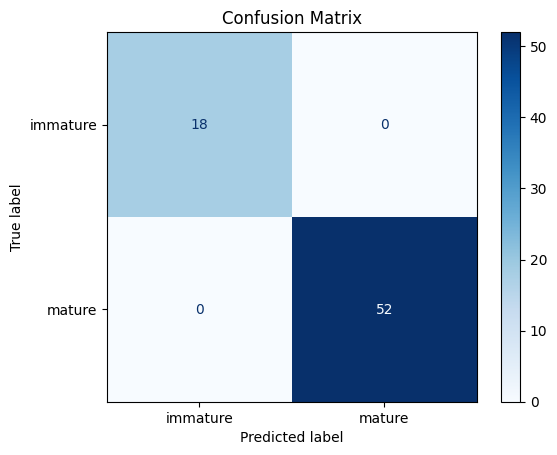

In [43]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score)

def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            out = model(x).cpu().numpy().ravel()
            y_prob.extend(out)
            y_pred.extend((out >= 0.5).astype(int))
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

y_true, y_pred, y_prob = evaluate(model, test_loader)

print(f"Test Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix'); plt.show()

## 10. 儲存 / 載入模型 (.pth)




In [44]:
import torch

SAVE_PATH = "cataract_resnet50.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "classes": classes,
    "input_size": 224,
    "arch": "resnet50",
}, SAVE_PATH)
print(f"已儲存到 {SAVE_PATH}")

from google.colab import files
files.download(SAVE_PATH)

已儲存到 cataract_resnet50.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
checkpoint = torch.load(SAVE_PATH, map_location=device)

loaded_model = build_model()
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.to(device).eval()

classes = checkpoint["classes"]
print("載入完成,類別:", classes)

model = loaded_model

載入完成,類別: ['immature', 'mature']


## 11. (選用) GroupKFold 交叉驗證

只有 410 張、單次切分波動大。因此用5-fold依原圖分組做交叉驗證,
讓結果更可信。

In [46]:
RUN_CROSS_VALIDATION = True   # 想跑交叉驗證就改成 True

if RUN_CROSS_VALIDATION:
    from sklearn.model_selection import GroupKFold
    from sklearn.metrics import f1_score

    gkf = GroupKFold(n_splits=5)
    fold_acc, fold_f1 = [], []

    for fold, (tr, te) in enumerate(gkf.split(np.arange(n_files), targets, groups), 1):
        tr_loader = torch.utils.data.DataLoader(
            torch.utils.data.Subset(dataset, tr), batch_size=16, shuffle=True)
        te_loader = torch.utils.data.DataLoader(
            torch.utils.data.Subset(dataset, te), batch_size=16, shuffle=False)

        m = build_model()
        opt = torch.optim.SGD(m.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
        print(f"\nFold {fold}")
        m, _ = train_model(m, tr_loader, opt, criterion, epochs=8,
                           val_loader=te_loader, early_stopping=True, early_stopping_patience=3)

        yt, yp, _ = evaluate(m, te_loader)
        acc = accuracy_score(yt, yp); f1 = f1_score(yt, yp)
        fold_acc.append(acc); fold_f1.append(f1)
        print(f"Fold {fold}: Acc={acc*100:.2f}%  F1={f1:.4f}")

    print("\n交叉驗證結果")
    print(f"Accuracy: {np.mean(fold_acc)*100:.2f}% ± {np.std(fold_acc)*100:.2f}%")
    print(f"F1 score: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
else:
    print("已跳過交叉驗證")


Fold 1
Epoch 1 | Train Loss 0.5564 | Train Acc 71.34% | Val Loss 0.6306 | Val Acc 82.93%
Epoch 2 | Train Loss 0.1023 | Train Acc 98.48% | Val Loss 0.5881 | Val Acc 92.68%
Epoch 3 | Train Loss 0.0290 | Train Acc 99.09% | Val Loss 0.1956 | Val Acc 92.68%
Epoch 4 | Train Loss 0.0148 | Train Acc 99.70% | Val Loss 0.1388 | Val Acc 97.56%
Epoch 5 | Train Loss 0.0246 | Train Acc 99.09% | Val Loss 0.0573 | Val Acc 97.56%
Epoch 6 | Train Loss 0.0584 | Train Acc 98.48% | Val Loss 0.2609 | Val Acc 89.02%
Epoch 7 | Train Loss 0.0206 | Train Acc 99.70% | Val Loss 0.1777 | Val Acc 92.68%
Epoch 8 | Train Loss 0.0114 | Train Acc 99.70% | Val Loss 0.0456 | Val Acc 98.78%
Fold 1: Acc=98.78%  F1=0.9867

Fold 2
Epoch 1 | Train Loss 0.5696 | Train Acc 70.73% | Val Loss 0.3021 | Val Acc 97.56%
Epoch 2 | Train Loss 0.0922 | Train Acc 98.78% | Val Loss 0.1095 | Val Acc 93.90%
Epoch 3 | Train Loss 0.0198 | Train Acc 99.39% | Val Loss 0.0182 | Val Acc 100.00%
Epoch 4 | Train Loss 0.0097 | Train Acc 99.70% | Va

## 12. 上傳自己的圖片做預測


模型會判斷每張是 immature 還是 mature 白內障,並顯示信心分數。

請上傳要預測的圖片 (可多選):


Saving mature_v2.png to mature_v2 (1).png


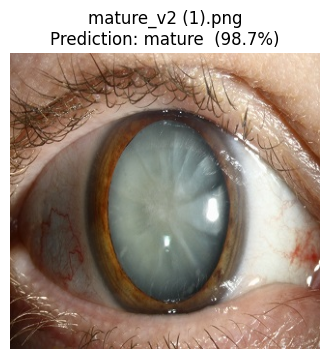

mature_v2 (1).png -> mature  (信心 98.7%)


In [47]:
from PIL import Image
from google.colab import files

def predict_image(pil_img):
    img = pil_img.convert("RGB")
    x = transform_train(img).to(device).unsqueeze(0)
    model.eval()
    with torch.no_grad():
        prob = model(x).item()
    pred_idx = int(prob >= 0.5)
    confidence = prob if pred_idx == 1 else 1 - prob
    return classes[pred_idx], confidence

print("請上傳要預測的圖片 (可多選):")
uploaded = files.upload()

for fname in uploaded:
    img = Image.open(fname)
    label, conf = predict_image(img)
    plt.figure(figsize=(4, 4))
    plt.imshow(img.convert("RGB"))
    plt.title(f"{fname}\nPrediction: {label}  ({conf*100:.1f}%)")
    plt.axis("off"); plt.show()
    print(f"{fname} -> {label}  (信心 {conf*100:.1f}%)")